## Análise — Bubble 

Notebook para análise de variação dos parâmetros do Bubble.

- Versão do simulador que automatiza alguns passos para facilitar a análise de variação de parâmetros.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Any

from bubble import BubbleModel, DEFAULT_CONFIG, create_model
from bubble.affinity import cosine_similarity, dot_product
from bubble.selection import select_by_max_degree, select_randomly
from bubble.messages import opposite_uniform_message, opposite_unique_message
from bubble.metrics import cross_group_connectivity, modularity_value, assortativity_value
from bubble.scaling import constant_scaling, linear_scaling, log_scaling, power_law_scaling, sqrt_scaling

In [2]:
metric_options = {
    'cross_group_connectivity': cross_group_connectivity,
    'modularity_value': modularity_value,
    'assortativity_value': assortativity_value
}

In [3]:
PARAM_SPACE = {
    "num_nodes": [10, 20, 35, 50, 75, 100],
    "words_per_node": [(4,4), (7,7), (12,12), (25,25), (50,50), (100,100)],
    "affinity_level": [0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9],
    "beta": [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
    "gamma": [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
    "affinity": [cosine_similarity, dot_product],
    "influencer_selection": [select_by_max_degree, select_randomly],
    "influencer_scaling": [constant_scaling(2), constant_scaling(4), linear_scaling(0.1), log_scaling(2)],
    "bubble_burst_metric_name": ['cross_group_connectivity', 'modularity_value', 'assortativity_value'],
    "message_generator": [opposite_uniform_message, opposite_unique_message],
    "num_iterations": [5, 10, 20, 50, 100, 200],
    "alphaL": [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
    "alphaR": [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
}

In [4]:
def variate_parameters(param_space: dict[str, list], samples: list[str], varying: str, num_runs: int = 10, fixed: dict[str, Any]|None = None) -> None:
    """ Variates a given parameter across a range of values while keeping other parameters constant, and runs the model for each value.
    Optionally, some parameters can be sampled randomly from the parameter space. Generates plots of the results for each configuration.

    Parameters
    ----------
    param_space : dict[str, list]
        A dictionary where keys are parameter names and values are lists of possible values for those parameters.
    samples : list[str]
        A list of parameter names to be randomly sampled from the parameter space for each run.
    varying : str
        The name of the parameter to be varied across its range of values.
    num_runs : int, optional
        The number of times to run the model for each value of the varying parameter.
    fixed : dict[str, Any], optional
        A dictionary of parameters to be fixed at specific values for all runs. Use the default configuration for any parameters not specified here.

    Returns
    -------
    None
        This function does not return a value. It generates and displays plots of the results inline.
    """

    if fixed is None:
        fixed = {}

    if varying not in param_space:
        raise ValueError(f"Parameter '{varying}' not found in parameter space.")
    
    def select_with_precedence(param: str) -> Any:
        if param in fixed:
            return fixed[param]
        elif param in samples:
            return param_space[param][np.random.randint(0, len(param_space[param]))]
        elif param in DEFAULT_CONFIG:
            return DEFAULT_CONFIG[param]
        else:
            return param_space[param][0]
    
    cols = 1
    rows = int(np.ceil(num_runs / cols)) 
    fig, axes = plt.subplots(rows, cols, figsize=(18 * cols, 5 * rows), squeeze=False)
    axes = axes.flatten()

    all_keys = set(DEFAULT_CONFIG.keys()).union(param_space.keys())

    for run_index in range(num_runs):
        
        CURRENT_CONFIG: dict[str, Any] = {
            key: select_with_precedence(key) for key in all_keys
        }

        print(f"\n--- Run {run_index + 1}/{num_runs} ---")
        print("Base Config:")
        for k, v in CURRENT_CONFIG.items():
            if k != varying:
                val_rep = getattr(v, '__name__', str(v))
                print(f"  {k}: {val_rep}")
        print(f"Varying {varying} => ", end='')
        first_cross_edge_time = []

        ax = axes[run_index]
        n_iters = CURRENT_CONFIG['num_iterations']
        msg_generator = CURRENT_CONFIG['message_generator']
        colors = plt.get_cmap('tab10')(np.linspace(0, 1, len(param_space[varying])))

        for i, value in enumerate(param_space[varying]):
            print(f"{value}", end=' ')
            CURRENT_CONFIG[varying] = value
            
            varying_config = create_model(CURRENT_CONFIG)
            model = BubbleModel(varying_config)
            
            wpn = model.words_per_node
            msg0 = msg_generator(wpn, 0)
            msg1 = msg_generator(wpn, 1)
            
            model.run(n_iters, msg0, msg1)
            label_name = getattr(value, '__name__', str(value))
            first_cross_edge_time.append(model.cross_edge_time)
            
            model.plot_bubble_burst(
                ax=ax, 
                show=False,
                title=f"Run {run_index + 1}",
                label=f"{varying}: {label_name}",
                color=colors[i]
            )
            
        print(f'\nFirst Cross Edge =>',end=' ')
        print(first_cross_edge_time,end='\n\n')
        ax.grid(True, linestyle='--', alpha=0.6)

        primary_legend = ax.legend(
            fontsize='small', 
            loc='upper left', 
            bbox_to_anchor=(1.0, 1)
        )
        ax.add_artist(primary_legend)
        
        if samples:
            sample_handles = []
            sample_labels = [] 
            for s in samples:
                val = CURRENT_CONFIG[s]
                val_str = getattr(val, '__name__', str(val))
                dummy_line, = ax.plot([], [], marker="", ls="")
                sample_handles.append(dummy_line)
                sample_labels.append(f"{s}: {val_str}")
            
            ax.legend(
                handles=sample_handles, 
                labels=sample_labels, 
                loc='lower left', 
                bbox_to_anchor=(1.0, 0),
                fontsize='small'
            )

    for i in range(num_runs, len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout(rect=(0, 0, 0.6, 1))
    plt.show()


--- Run 1/4 ---
Base Config:
  affinity_level: 0.7
  affinity: cosine_similarity
  influencer_selection: select_by_max_degree
  bubble_burst_metric: cross_group_connectivity
  message_generator: opposite_uniform_message
  alphaL: None
  bubble_burst_metric_name: cross_group_connectivity
  labels: []
  alphaR: None
  beta: 0.7
  influencer_scaling: const_rule
  gamma: 1.0
  num_iterations: 50
  words_per_node: (4, 4)
Varying num_nodes => 10 20 35 50 75 100 
First Cross Edge => [1, 1, 1, 1, 1, 1]


--- Run 2/4 ---
Base Config:
  affinity_level: 0.05
  affinity: cosine_similarity
  influencer_selection: select_by_max_degree
  bubble_burst_metric: cross_group_connectivity
  message_generator: opposite_uniform_message
  alphaL: None
  bubble_burst_metric_name: cross_group_connectivity
  labels: []
  alphaR: None
  beta: 0.7
  influencer_scaling: const_rule
  gamma: 0.1
  num_iterations: 50
  words_per_node: (4, 4)
Varying num_nodes => 10 20 35 50 75 100 
First Cross Edge => [1, 1, 1, 1, 1,

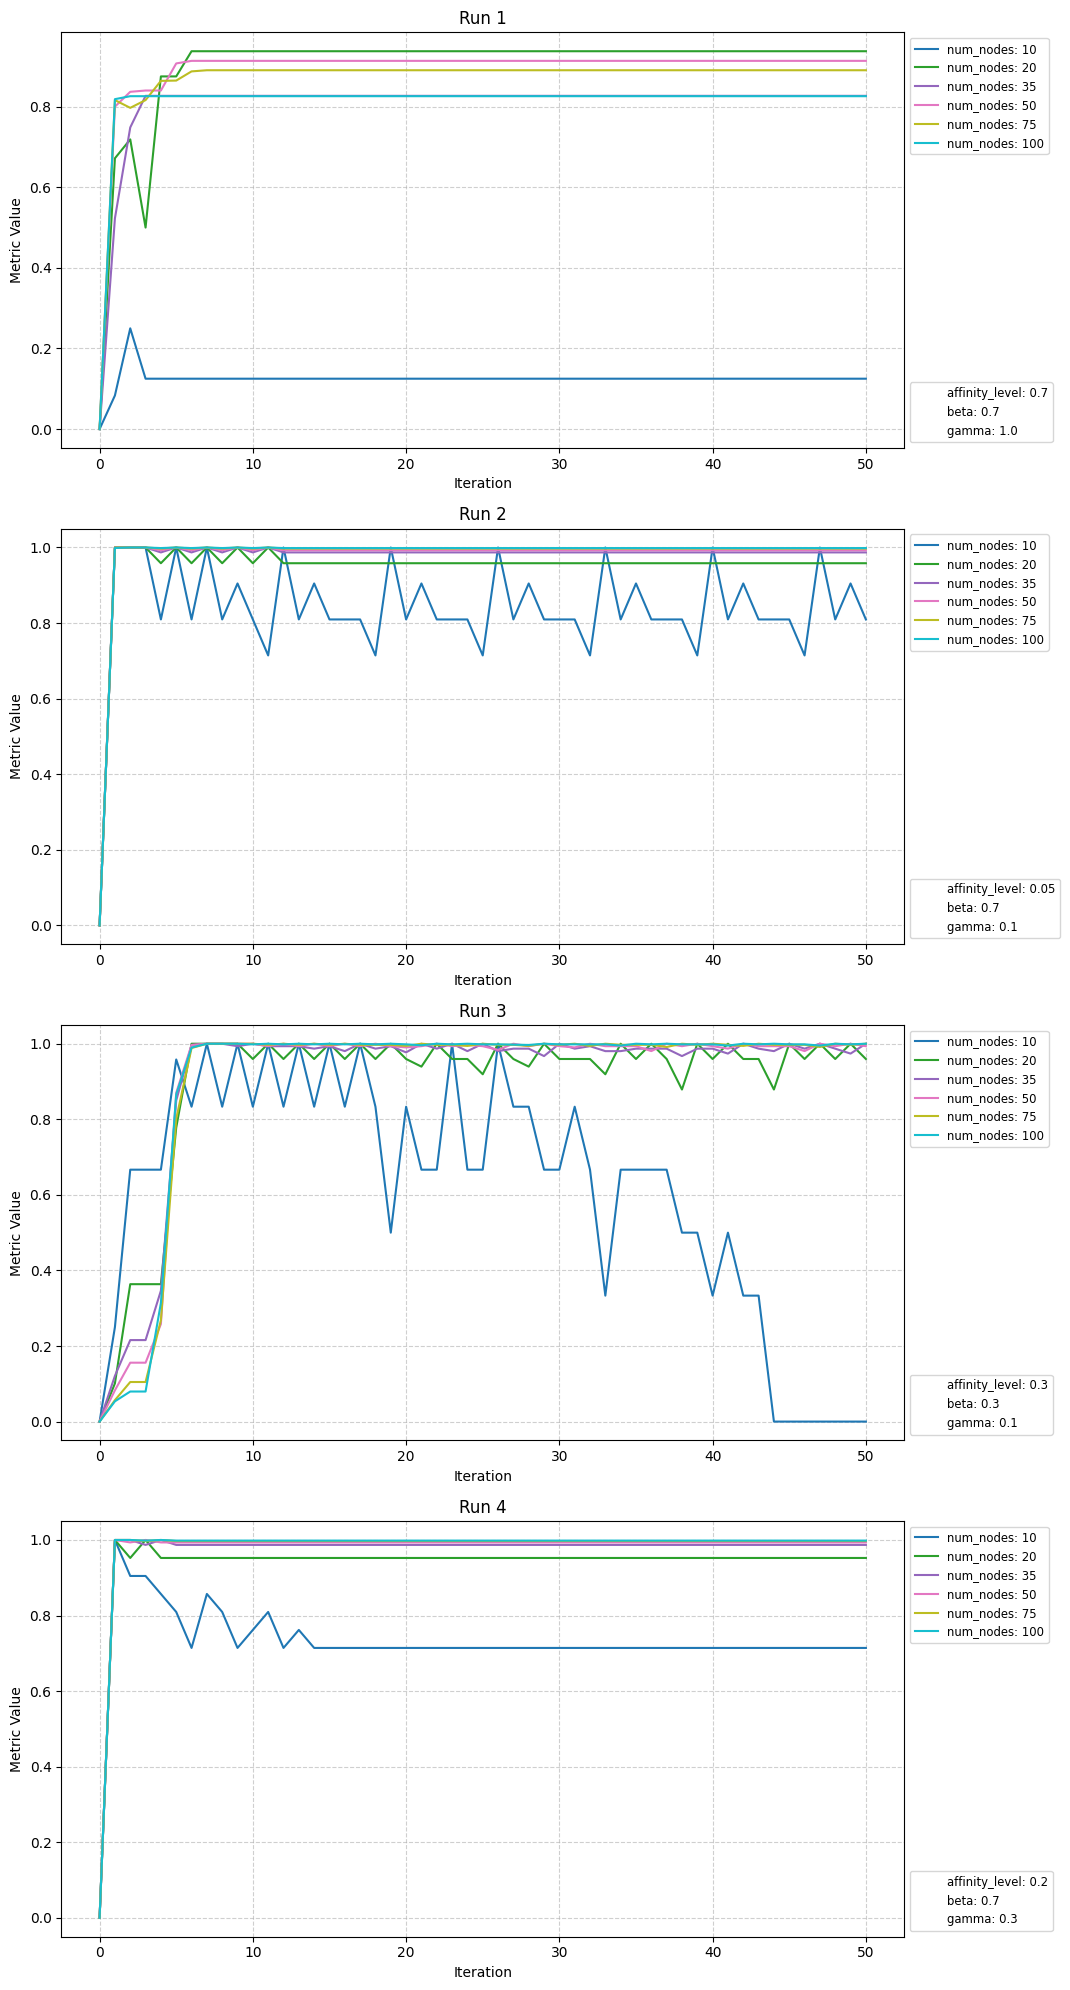

In [5]:
variate_parameters(
    param_space=PARAM_SPACE,
    samples=['affinity_level', 'beta', 'gamma'],
    varying='num_nodes',
    fixed={'num_iterations': 50},
    num_runs=4
)


--- Run 1/12 ---
Base Config:
  affinity_level: 0.01
  affinity: cosine_similarity
  influencer_selection: select_by_max_degree
  bubble_burst_metric: cross_group_connectivity
  message_generator: opposite_uniform_message
  alphaL: None
  bubble_burst_metric_name: cross_group_connectivity
  labels: []
  alphaR: None
  beta: 1.0
  influencer_scaling: const_rule
  gamma: 0.9
  num_iterations: 50
  words_per_node: (4, 4)
Varying num_nodes => 10 20 35 50 75 100 
First Cross Edge => [1, 1, 1, 1, 1, 1]


--- Run 2/12 ---
Base Config:
  affinity_level: 0.01
  affinity: cosine_similarity
  influencer_selection: select_by_max_degree
  bubble_burst_metric: cross_group_connectivity
  message_generator: opposite_uniform_message
  alphaL: None
  bubble_burst_metric_name: cross_group_connectivity
  labels: []
  alphaR: None
  beta: 1.0
  influencer_scaling: const_rule
  gamma: 0.5
  num_iterations: 50
  words_per_node: (4, 4)
Varying num_nodes => 10 20 35 50 75 100 
First Cross Edge => [1, 1, 1, 1,

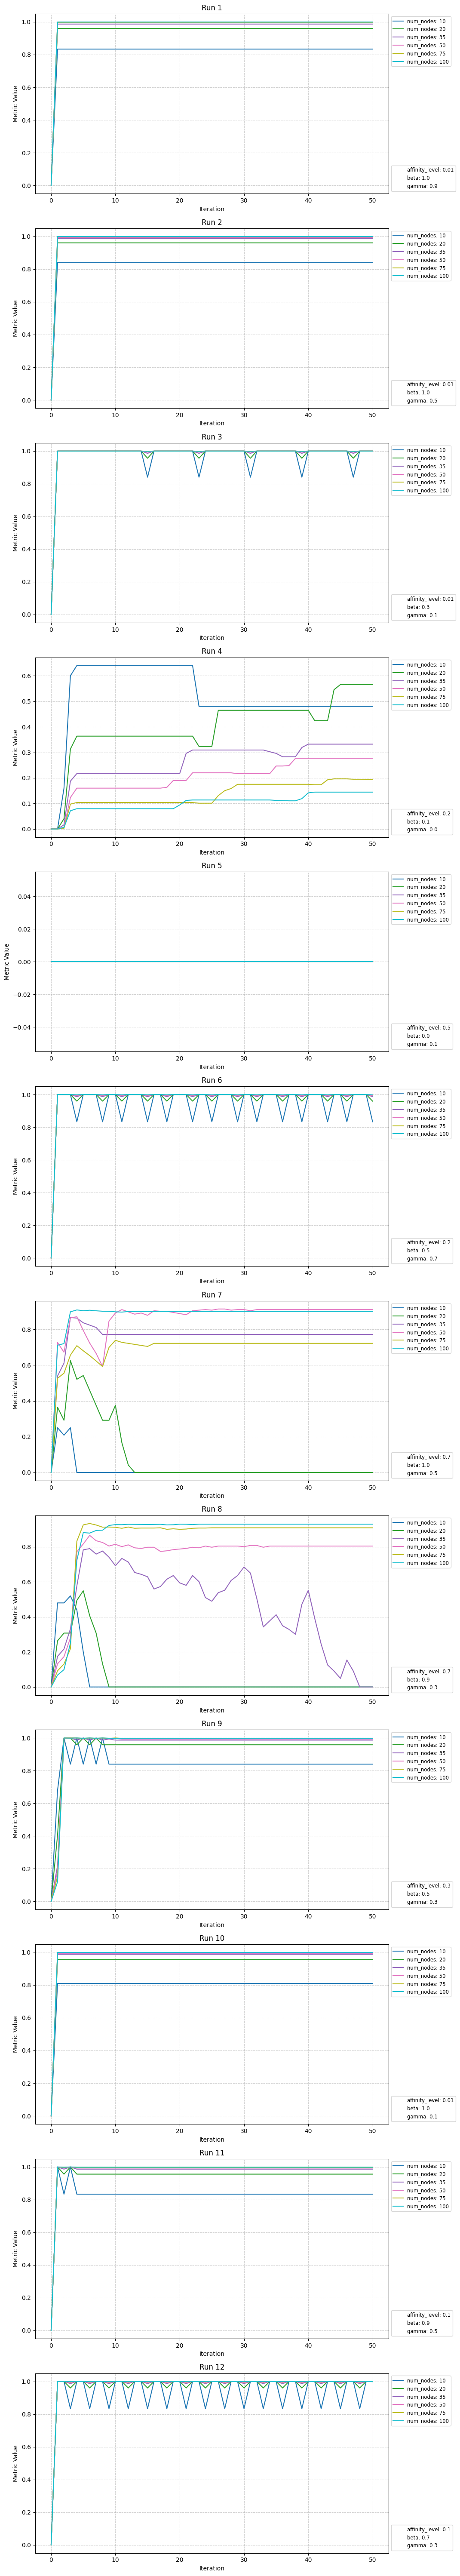

In [6]:
variate_parameters(
    param_space=PARAM_SPACE,
    samples=['affinity_level', 'beta', 'gamma'],
    varying='num_nodes',
    fixed={'num_iterations': 50},
    num_runs=12
)


--- Run 1/6 ---
Base Config:
  affinity_level: 0.3
  affinity: cosine_similarity
  influencer_selection: select_by_max_degree
  bubble_burst_metric: cross_group_connectivity
  message_generator: opposite_uniform_message
  alphaL: None
  labels: []
  alphaR: None
  beta: 0.7
  num_nodes: 75
  influencer_scaling: const_rule
  gamma: 1.0
  num_iterations: 100
  words_per_node: (100, 100)
Varying bubble_burst_metric_name => cross_group_connectivity modularity_value assortativity_value 
First Cross Edge => [1, 1, 1]


--- Run 2/6 ---
Base Config:
  affinity_level: 0.05
  affinity: cosine_similarity
  influencer_selection: select_by_max_degree
  bubble_burst_metric: cross_group_connectivity
  message_generator: opposite_uniform_message
  alphaL: None
  labels: []
  alphaR: None
  beta: 0.0
  num_nodes: 50
  influencer_scaling: const_rule
  gamma: 0.3
  num_iterations: 100
  words_per_node: (100, 100)
Varying bubble_burst_metric_name => cross_group_connectivity modularity_value assortativity

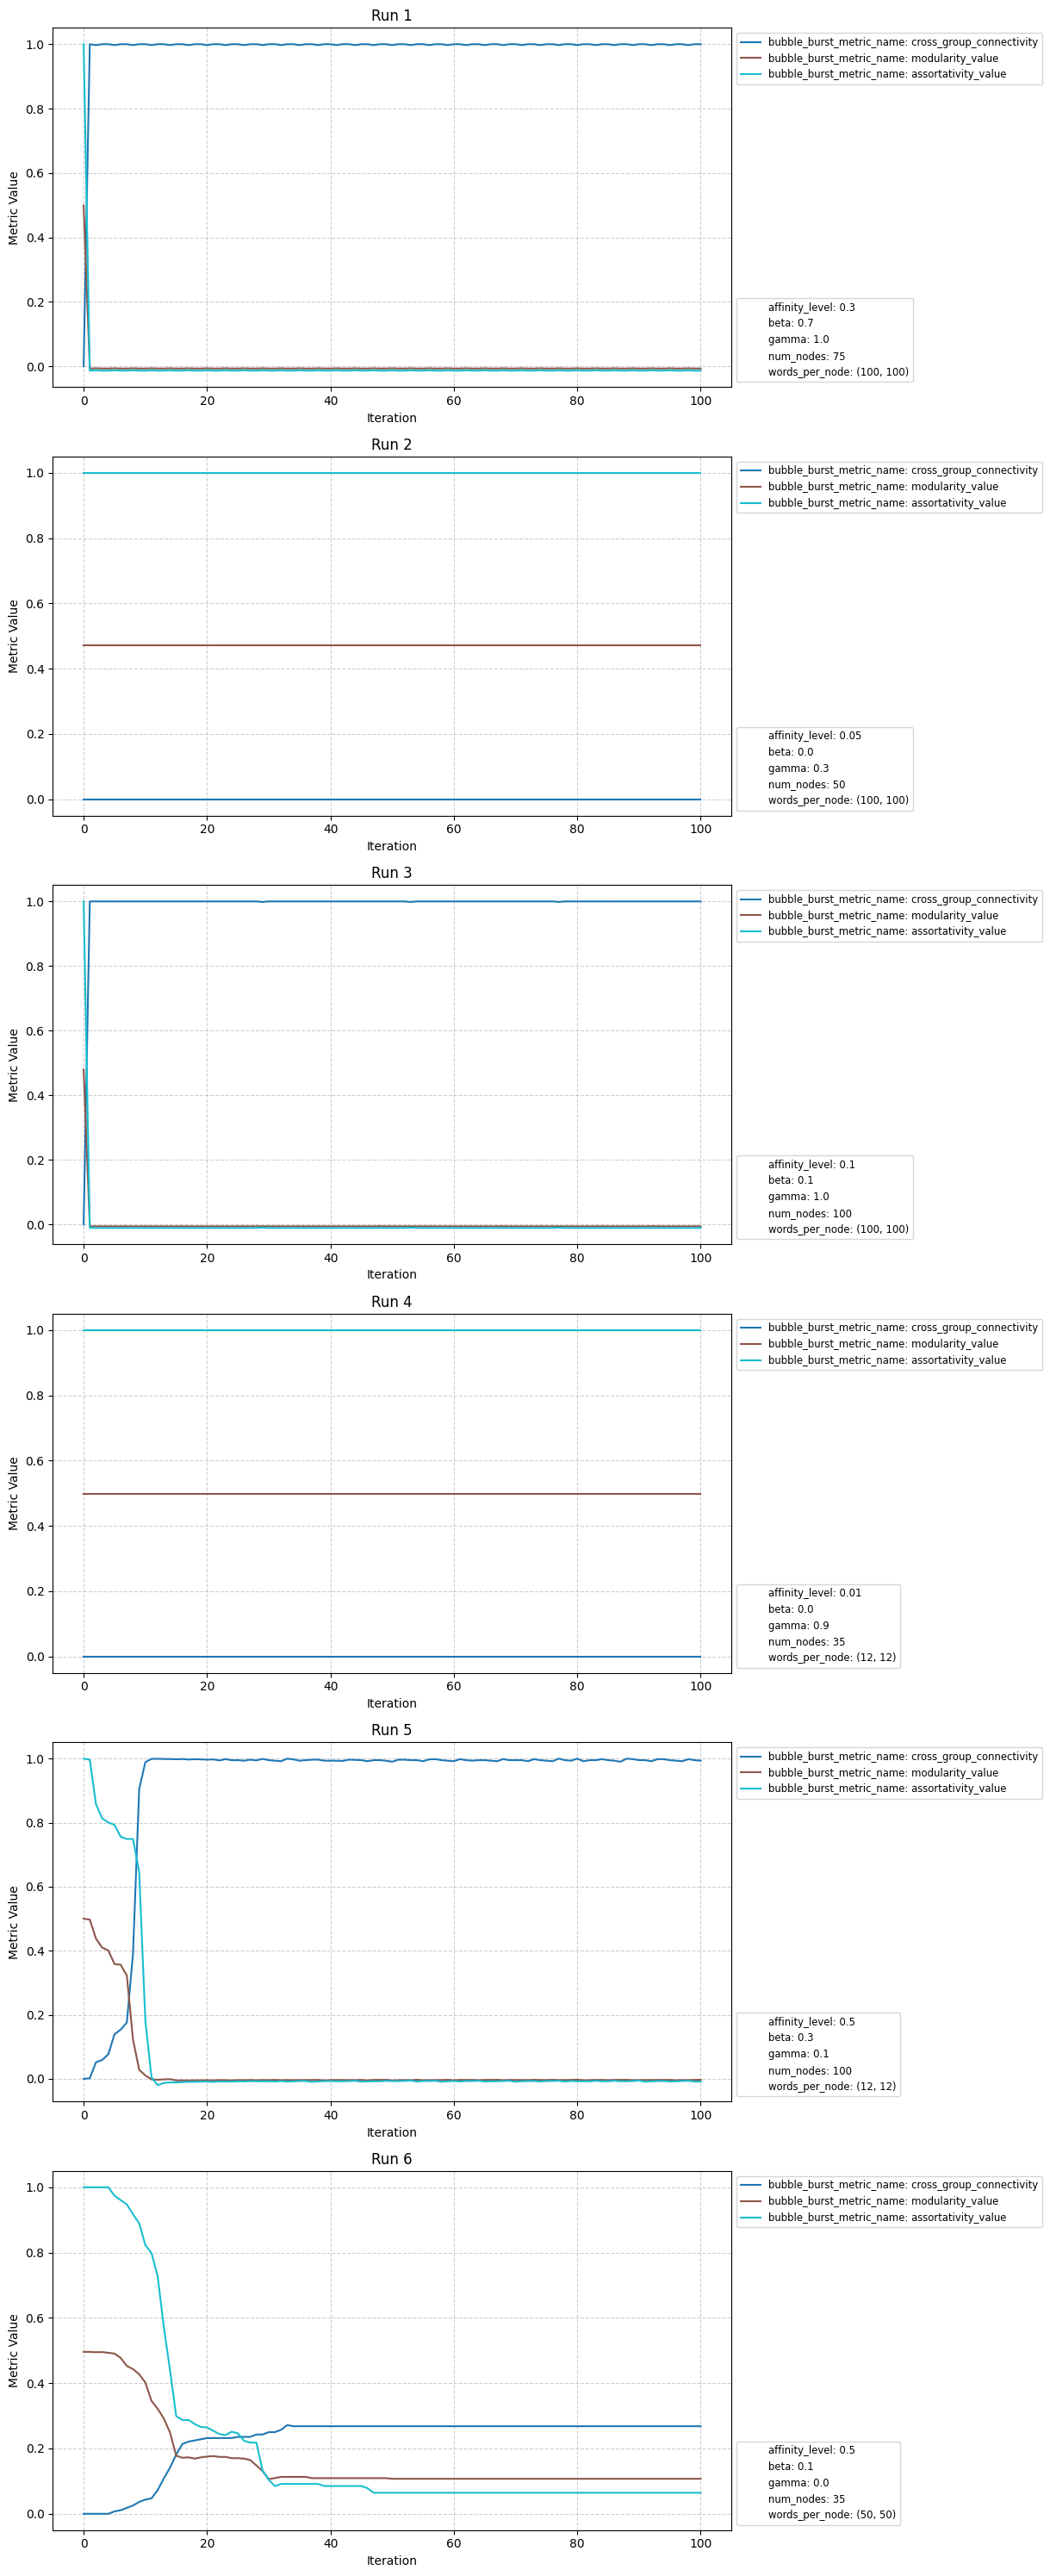

In [7]:
variate_parameters(
    param_space=PARAM_SPACE,
    samples=['affinity_level', 'beta', 'gamma', 'num_nodes', 'words_per_node'],
    varying='bubble_burst_metric_name',
    fixed={'num_iterations': 100},
    num_runs=6
)